PART C — GAN (Fashion-MNIST)

STEP 1: IMPORTS

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

STEP 2: LOAD DATASET

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)

loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.30MB/s]


STEP 3: GENERATOR

In [4]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),

            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)

STEP 4: DISCRIMINATOR

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x.view(-1, 28*28))

STEP 5: INITIALIZE MODELS

In [6]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

STEP 6: CREATE OUTPUT FOLDER

In [7]:
os.makedirs("gan_images", exist_ok=True)

STEP 7: TRAINING LOOP (IMPORTANT)

In [8]:
epochs = 30
z_dim = 100

G_losses = []
D_losses = []

for epoch in range(epochs):
    for real, _ in loader:
        real = real.to(device)
        batch_size = real.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        noise = torch.randn(batch_size, z_dim).to(device)
        fake = G(noise)

        D_real = D(real)
        D_fake = D(fake.detach())

        loss_D_real = criterion(D_real, real_labels)
        loss_D_fake = criterion(D_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        output = D(fake)
        loss_G = criterion(output, real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    G_losses.append(loss_G.item())
    D_losses.append(loss_D.item())

    print(f"Epoch [{epoch+1}/{epochs}]  Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

    # Save generated images every 5 epochs
    if (epoch+1) % 5 == 0:
        with torch.no_grad():
            sample_noise = torch.randn(16, z_dim).to(device)
            generated = G(sample_noise).cpu()

        fig, axes = plt.subplots(4,4, figsize=(4,4))
        for i, ax in enumerate(axes.flat):
            ax.imshow(generated[i].squeeze(), cmap='gray')
            ax.axis('off')

        plt.savefig(f"gan_images/epoch_{epoch+1}.png")
        plt.close()

Epoch [1/30]  Loss D: 1.0920, Loss G: 1.3854
Epoch [2/30]  Loss D: 1.1416, Loss G: 1.7370
Epoch [3/30]  Loss D: 1.2804, Loss G: 1.5838
Epoch [4/30]  Loss D: 1.3777, Loss G: 0.8247
Epoch [5/30]  Loss D: 1.3244, Loss G: 0.8005
Epoch [6/30]  Loss D: 1.2917, Loss G: 1.0922
Epoch [7/30]  Loss D: 1.2755, Loss G: 0.8962
Epoch [8/30]  Loss D: 1.3177, Loss G: 0.8393
Epoch [9/30]  Loss D: 1.2579, Loss G: 0.8214
Epoch [10/30]  Loss D: 1.3406, Loss G: 1.2964
Epoch [11/30]  Loss D: 1.2658, Loss G: 0.9045
Epoch [12/30]  Loss D: 1.3225, Loss G: 1.1809
Epoch [13/30]  Loss D: 1.3906, Loss G: 0.9499
Epoch [14/30]  Loss D: 1.4298, Loss G: 0.8699
Epoch [15/30]  Loss D: 1.2382, Loss G: 0.9293
Epoch [16/30]  Loss D: 1.3265, Loss G: 0.9193
Epoch [17/30]  Loss D: 1.3343, Loss G: 0.7462
Epoch [18/30]  Loss D: 1.3643, Loss G: 0.9745
Epoch [19/30]  Loss D: 1.2811, Loss G: 0.9646
Epoch [20/30]  Loss D: 1.3245, Loss G: 1.0790
Epoch [21/30]  Loss D: 1.3431, Loss G: 0.8290
Epoch [22/30]  Loss D: 1.3695, Loss G: 0.87

STEP 8: LOSS GRAPH (VERY IMPORTANT)

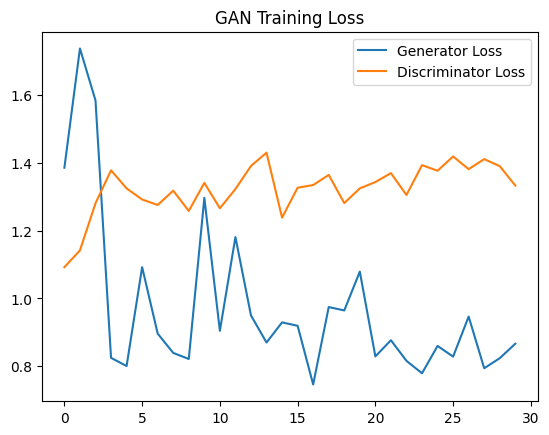

In [9]:
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.legend()
plt.title("GAN Training Loss")
plt.show()

STEP 9: SHOW FINAL GENERATED IMAGES

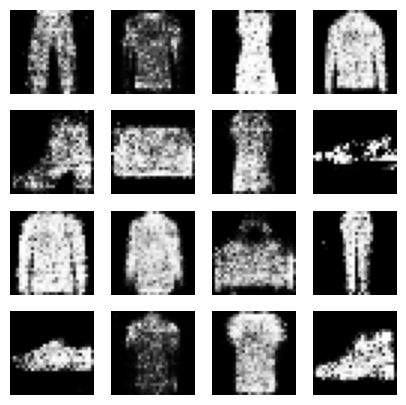

In [10]:
noise = torch.randn(16, z_dim).to(device)

with torch.no_grad():
    generated = G(noise).cpu()

fig, axes = plt.subplots(4,4, figsize=(5,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.show()